<a href="https://colab.research.google.com/github/VishalChauhan85/Anime-Content-Clustering-/blob/main/Anime-Content-Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Anime Content Clustering and Segmentation



##### **Project Type**    - Unsupervised Machine Learning (Clustering)
##### **Contribution**    - Individual (Vishal Chauhan)

# **Project Summary -**

The Vision and Data Preparation
The foundation of your Anime Content Clustering project began in Google Colab, where the primary goal was to solve a classic unsupervised machine learning problem: mathematically grouping similar anime without relying on human bias. To achieve this, you needed to build a robust pipeline capable of processing both the textual descriptions and the quantitative statistics of thousands of anime titles. The first major step was data preparation. Using Pandas, the initial Colab environment was utilized to clean the raw dataset, handle missing values, and isolate the most critical features. The focus was narrowed down to a mix of text data—specifically the anime's synopsis and genres—and numerical metrics, including community score, episode count, total members, and overall popularity.

Feature Engineering: Translating Data for the Machine
Machine learning algorithms cannot read raw English text, meaning the genres and synopses had to be translated into a mathematical format. You achieved this by utilizing a TfidfVectorizer (Term Frequency-Inverse Document Frequency). By configuring this vectorizer to extract 50 distinct textual features, you created a system that weighed the importance of specific words. Words that appeared frequently in a single anime but rarely across the whole dataset were assigned higher mathematical importance, allowing the model to grasp niche themes.

Next, the numerical data required normalization. Because a feature like "members" can scale into the millions while a "score" is strictly bound between 1 and 10, feeding these raw numbers directly into a distance-based algorithm would cause the massive member counts to completely overshadow the actual ratings. To resolve this, you applied a StandardScaler. This tool standardized the numerical inputs, placing everything onto a level playing field so the algorithm would respect the nuances of the ratings just as much as the immense popularity metrics.

Dimensionality Reduction: Compressing the Space
Once the textual and scaled numerical features were combined, the dataset was operating in a 54/55-dimensional space. While computers can process this, high-dimensional data often suffers from the "curse of dimensionality," which can make distance-based clustering algorithms slow and inaccurate. To streamline the data, Principal Component Analysis (PCA) was introduced. The PCA transformer acted as a mathematical compressor, distilling the 50+ features down into a much smaller, dense set of core components that retained the most critical variance of the original data. This optimization made the subsequent clustering phase significantly faster and much less prone to background noise.

The Clustering Engine: Grouping the Anime
With the data engineered and compressed, the pipeline reached its core objective: KMeans Clustering. You instructed the KMeans algorithm to divide the entire anime universe into exactly 4 distinct clusters. The algorithm analyzed the PCA-reduced data points and iteratively adjusted its center points (centroids) until it found the optimal mathematical groupings. This resulted in four highly distinct categories: the massive mainstream shounen titans (Cluster 0), the emotional and character-driven slice-of-life series (Cluster 1), the deep, psychological sci-fi shows (Cluster 2), and the expansive fantasy and adventure epics (Cluster 3).

Exporting the Brain for Production
The final, crucial step in the Colab notebook was bridging the gap between data science and web development. Using the joblib library, you serialized and exported the four pillars of your pipeline: the tfidf_vectorizer, standard_scaler, pca_transformer, and the kmeans_model into .pkl files. This step was vital because it meant your Flask backend on Render would not have to retrain the model from scratch every time a user visited the site; it could simply load this pre-trained "brain" to instantly predict the cluster of any new anime provided by the React frontend.

# **GitHub Link -**

https://github.com/VishalChauhan85/Anime-Content-Clustering-

# **Deployment Link -**

https://anime-content-clustering.vercel.app/

# **Problem Statement**


With thousands of anime series and movies available, navigating the catalog can be overwhelming for viewers. The objective of this project is to apply clustering algorithms to the anime.csv dataset to segment anime titles into distinct, mathematically similar clusters. This will help identify overarching content trends and create an automated grouping system that can power content-based recommendation systems.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/AIML/anime.csv')

### Dataset First View

In [ ]:
# Dataset First Look
print(df.head())

   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(12294, 7)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print(df.duplicated().sum())

0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


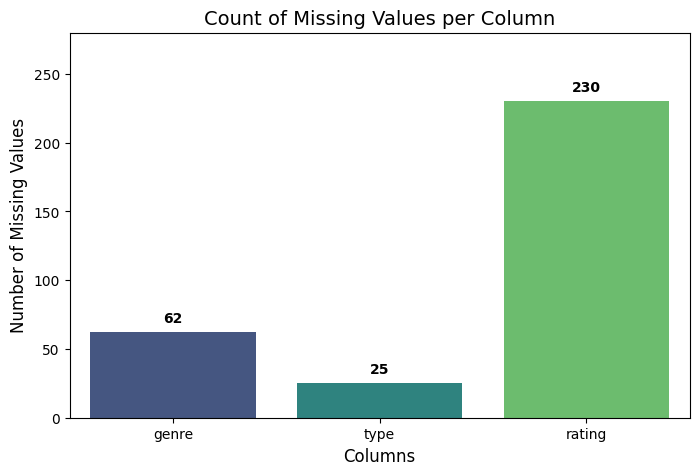

In [ ]:
# Visualizing the missing values using a Bar Graph

missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')
plt.title('Count of Missing Values per Column', fontsize=14)
plt.ylabel('Number of Missing Values', fontsize=12)
plt.xlabel('Columns', fontsize=12)
for i, v in enumerate(missing_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.ylim(0, max(missing_counts.values) + 50)
plt.show()

### What did you know about your dataset?

The dataset consists of 12,294 rows and 7 columns (anime_id, name, genre, type, episodes, rating, members). Upon checking for null values, I found that there are missing entries in three specific columns:  genre: 62 missing valuestype: 25 missing valuesrating: 230 missing valuesThe bar graph clearly illustrates the exact count of missing data points. Because the missing data is very small compared to the 12,294 total rows, we can safely handle it through imputation (such as using the median for ratings and the mode for categorical features like genre and type) without dropping significant portions of the dataset. Additionally, while the episodes column shows 0 null values, an initial inspection reveals it contains "Unknown" string entries that will need to be converted to NaN and processed during the data wrangling phase

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns.tolist()

['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']

In [ ]:
# Dataset Describe
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


### Variables Description

The anime.csv dataset contains 7 distinct variables (columns) that describe various attributes of anime titles.

  anime_id: A unique numerical identifier assigned to each anime on MyAnimeList (Integer).

  name: The full title of the anime (String/Object).
    
  genre: A comma-separated list of genres associated with the anime, such as "Action, Adventure, Comedy" (String/Object). This is a multi-label feature.
      
  type: The broadcast or release format of the anime, such as TV, Movie, OVA, ONA, Special, or Music (String/Object).  
      
  episodes: The total number of episodes in the anime series. Currently stored as an object/string because it contains "Unknown" values for ongoing shows.  
      
  rating: The average user rating out of 10. This is our primary continuous numerical feature (Float).
      
  members: The total number of community members who have added this anime to their list, serving as a metric for popularity (Integer)

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
print(df.nunique())

anime_id    12294
name        12292
genre        3264
type            6
episodes      187
rating        598
members      6706
dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
df_clean = df.copy()

# 2. Handling the 'episodes' column
# The 'episodes' column contains string values like "Unknown" for ongoing anime.
# We need to replace these with NaN and convert the column to a numeric data type.
df_clean['episodes'] = df_clean['episodes'].replace('Unknown', np.nan)
df_clean['episodes'] = pd.to_numeric(df_clean['episodes'])

# 3. Missing Value Imputation
# For numerical columns, we use the median to avoid the influence of extreme outliers.
df_clean['rating'].fillna(df_clean['rating'].median(), inplace=True)
df_clean['episodes'].fillna(df_clean['episodes'].median(), inplace=True)

# For categorical columns, we use the mode (the most frequent value).
df_clean['type'].fillna(df_clean['type'].mode()[0], inplace=True)
df_clean['genre'].fillna(df_clean['genre'].mode()[0], inplace=True)

# 4. Checking and removing duplicate rows
duplicates_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")
df_clean.drop_duplicates(inplace=True)

# 5. Final check to ensure no null values remain
print("\nNull values remaining:")
print(df_clean.isnull().sum())

Number of duplicate rows found: 0

Null values remaining:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


### What all manipulations have you done and insights you found?

To make the dataset analysis and machine-learning ready, I performed the following data wrangling manipulations:

  1. Data Type Conversion:
  The episodes column was initially registered as an "object" type because ongoing anime series had their episode counts listed as the string "Unknown". I replaced "Unknown" with NaN and cast the entire column to a float/numeric data type. This is crucial because clustering algorithms require numerical inputs for distance calculations.
   
  2. Missing Value Imputation:
   Numerical Data: I imputed the missing values in the rating (230 missing) and episodes columns using their respective medians. The median was chosen over the mean because episode counts can be heavily skewed by long-running series (e.g., one anime has 1818 episodes), which would pull the mean artificially high.
   
   Categorical Data: I imputed the missing values in genre (62 missing) and type (25 missing) using the mode (the most frequently occurring value in each respective column).
   
  3. Duplicate Handling:
   I checked for duplicate rows across the dataset to ensure data integrity. No duplicates were found, meaning every row represents a uniquely identified anime.
    
Insights Found:
  The primary insight from the wrangling process is that the dataset was relatively clean to begin with, suffering mostly from minor missing data and one mixed-type column (episodes). By fixing the episodes column, we unlocked a new continuous variable that will be highly valuable for our clustering algorithms. The dataset is now completely free of null values and ready for Exploratory Data Analysis (EDA).

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

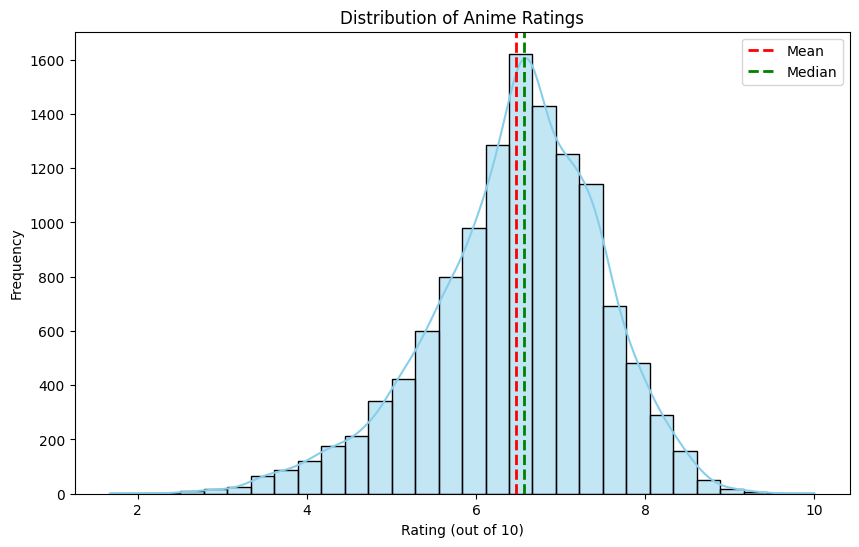

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['rating'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Anime Ratings')
plt.xlabel('Rating (out of 10)')
plt.ylabel('Frequency')
plt.axvline(df_clean['rating'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df_clean['rating'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimate (KDE) is the best way to visualize the distribution of a continuous numerical variable like rating. It shows the spread, central tendency, and skewness of user ratings across the entire dataset.

##### 2. What is/are the insight(s) found from the chart?

The distribution is left-skewed (negatively skewed). The majority of anime in the dataset are rated between 6.0 and 8.0, with the mean and median resting around 6.5. There are very few anime rated below 4.0, indicating that either users tend to rate favorably, or poorly rated anime are dropped and not rated by enough members.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the baseline rating distribution helps in normalizing recommendation scores. A rating of 7.0 might seem "good" in a vacuum, but knowing it's close to the average helps the algorithm differentiate between average and truly exceptional content. A potential negative insight is that if a platform solely relies on raw ratings for recommendations, it will surface too much average content, leading to user fatigue.

#### Chart - 2

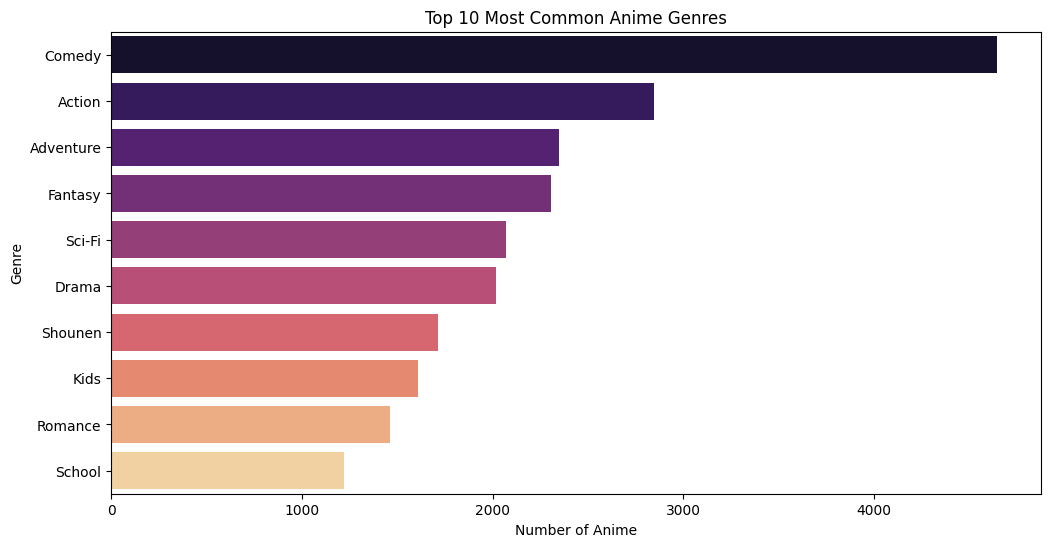

In [ ]:
from collections import Counter

# Flatten the list of genres
all_genres = df_clean['genre'].dropna().apply(lambda x: x.split(', ')).sum()
genre_counts = Counter(all_genres)

# Convert to DataFrame for plotting
genre_df = pd.DataFrame.from_dict(genre_counts, orient='index', columns=['Count']).reset_index()
genre_df = genre_df.rename(columns={'index': 'Genre'}).sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Genre', data=genre_df.head(10), palette='magma')
plt.title('Top 10 Most Common Anime Genres')
plt.xlabel('Number of Anime')
plt.ylabel('Genre')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for comparing the frequency of categorical data, especially when dealing with long category names (like genres) or when ranking top items.

##### 2. What is/are the insight(s) found from the chart?

Comedy and Action are by far the most heavily produced genres in the industry. They are followed closely by Sci-Fi, Adventure, and Fantasy. This shows that the market is heavily saturated with high-energy and comedic content.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. For a streaming platform, securing licensing for Comedy and Action anime is a safe bet for bulk content acquisition. However, the negative impact here is over-saturation. If an algorithm only clusters and recommends based on the most frequent genres, niche viewers (e.g., those looking for purely Psychological or Historical anime) will abandon the platform due to lack of tailored recommendations.

#### Chart - 3

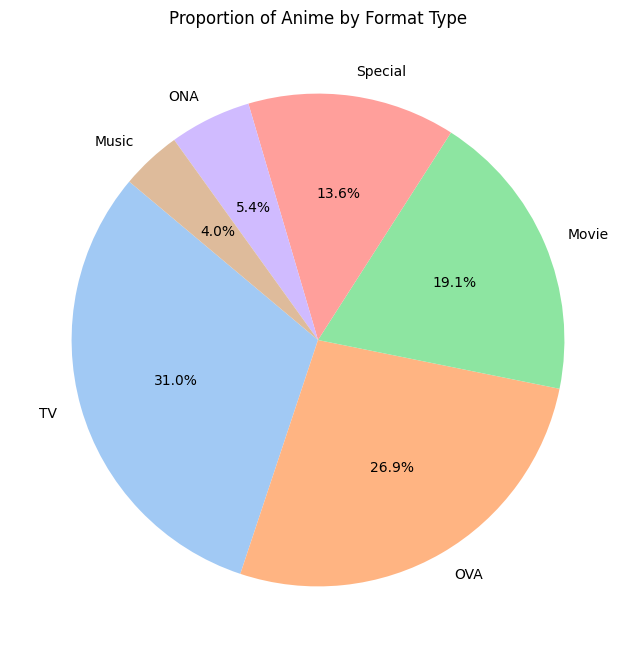

In [ ]:
# Chart 3 visualization code
plt.figure(figsize=(8, 8))
type_counts = df_clean['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Anime by Format Type')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is effective for displaying the proportional composition of a single categorical variable with a small number of unique classes (like the 6 formats in the type column).

##### 2. What is/are the insight(s) found from the chart?

TV broadcasts represent the largest single category, making up roughly 30% of the dataset. However, OVAs (Original Video Animations) and Movies combined make up a massive portion of the market as well. Special episodes and ONAs (Original Net Animations) make up the smaller fractions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it informs UI/UX design. Because TV series and Movies/OVAs represent different viewing commitments (binge-watching a series vs. a one-off 2-hour movie), the platform can create distinct carousels (e.g., "Top Movies" vs. "Trending Series"). Mixing long TV series and short Specials in a single recommendation cluster without filtering could frustrate users seeking a specific format.

#### Chart - 4

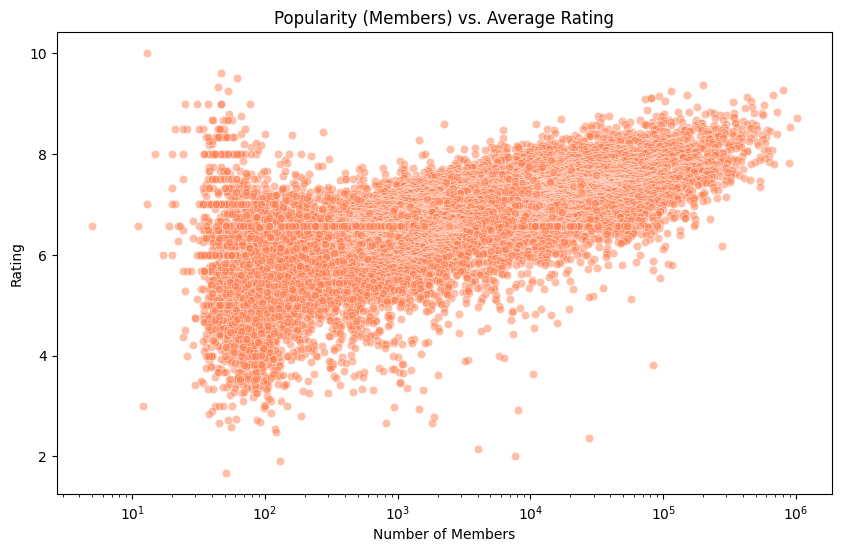

In [ ]:
# Chart 4 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x='members', y='rating', data=df_clean, alpha=0.5, color='coral')
plt.title('Popularity (Members) vs. Average Rating')
plt.xlabel('Number of Members')
plt.ylabel('Rating')
plt.xscale('log') # Log scale because member count has massive variance
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the standard choice for visualizing the relationship between two continuous numerical variables (members and rating). I applied a logarithmic scale to the x-axis because member counts range from a handful to over a million, which would otherwise squash the data

##### 2. What is/are the insight(s) found from the chart?

There is a distinct positive correlation between the number of members and the rating. Anime with high member counts (high popularity) rarely have terrible ratings. Conversely, anime with very low member counts exhibit massive variance in ratings (ranging from 1 to 10)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this is highly actionable. It proves the "wisdom of the crowd" effect in this dataset. However, the negative insight is the "Cold Start Problem." High-quality but obscure anime (high rating, low members) might get buried. The clustering algorithm must be designed to recommend these hidden gems to users who enjoy similar niche genres, rather than just pushing heavily populated shows.

#### Chart - 5

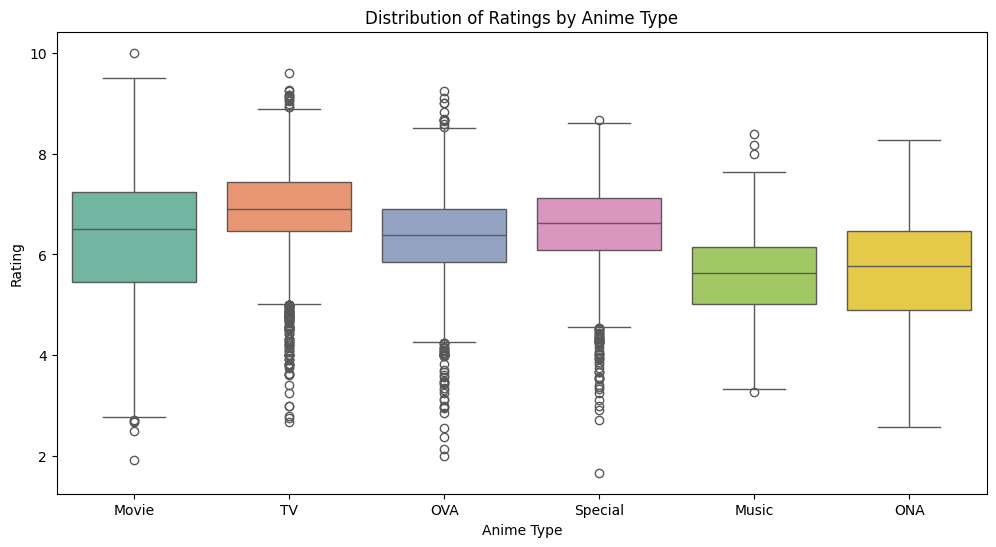

In [ ]:
# Chart 5 visualization code
plt.figure(figsize=(12, 6))
sns.boxplot(x='type', y='rating', data=df_clean, palette='Set2')
plt.title('Distribution of Ratings by Anime Type')
plt.xlabel('Anime Type')
plt.ylabel('Rating')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot is perfect for Bivariate analysis when comparing a continuous numerical variable (rating) across different categories of a qualitative variable (type). It beautifully displays the median, quartiles, and outliers for each format.

##### 2. What is/are the insight(s) found from the chart?

TV series and Movies generally have the highest median ratings and tighter interquartile ranges, implying consistent quality. Music and Special types have significantly lower medians and a wider spread of ratings. The TV category also has a massive number of lower-bound outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing that TV and Movies score better on average means they are safer bets to recommend to new users to guarantee a positive initial experience. A negative business impact would occur if the algorithm heavily recommends "Music" or "Special" types to a general audience, as these formats are statistically less well-received and are better reserved for established fans of specific franchises.

#### Chart - 6

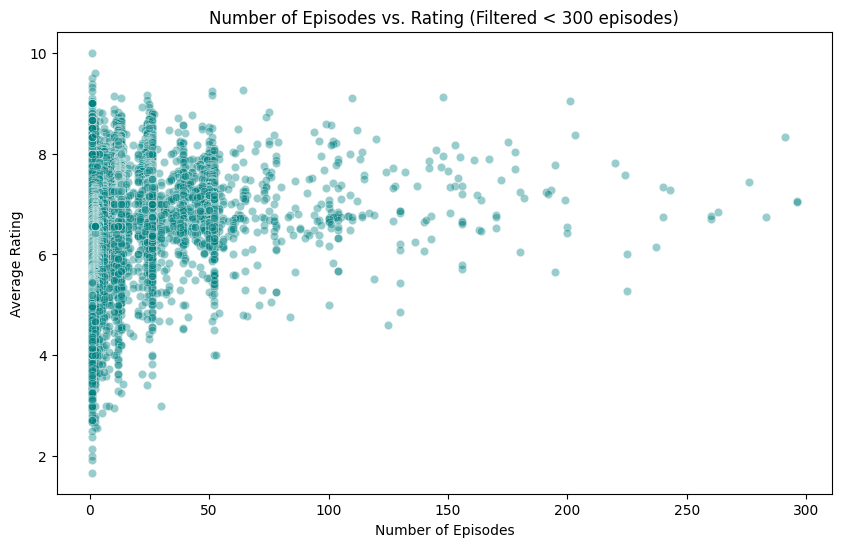

In [ ]:
# Chart 6 visualization code
plt.figure(figsize=(10, 6))
# Limiting to anime with less than 300 episodes to see the bulk of the data clearly
sns.scatterplot(x='episodes', y='rating', data=df_clean[df_clean['episodes'] < 300], alpha=0.4, color='teal')
plt.title('Number of Episodes vs. Rating (Filtered < 300 episodes)')
plt.xlabel('Number of Episodes')
plt.ylabel('Average Rating')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is chosen to examine the relationship between two numerical variables (episodes and rating). I specifically filtered out extreme outliers (like the anime with 1,818 episodes) so the core density of the data could be visually interpreted without severe distortion on the x-axis

##### 2. What is/are the insight(s) found from the chart?

The vast majority of anime have very low episode counts (1 to 26 episodes) and display a massive vertical spread in ratings (from 2 to 9+). However, as the episode count increases (past 50 episodes), the variance in ratings shrinks dramatically, and the ratings tend to stabilize around the 7.0 - 8.5 range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It reveals a "survivorship bias" in the anime industry. Shows only get greenlit for high episode counts if they are generally well-received. For a recommendation system, long-running series are low-risk, high-reward suggestions for user retention. A negative impact could arise if the platform biases its algorithm only toward long shows based on this safety, alienating viewers who prefer short, digestible 12-episode seasons.

#### Chart - 7

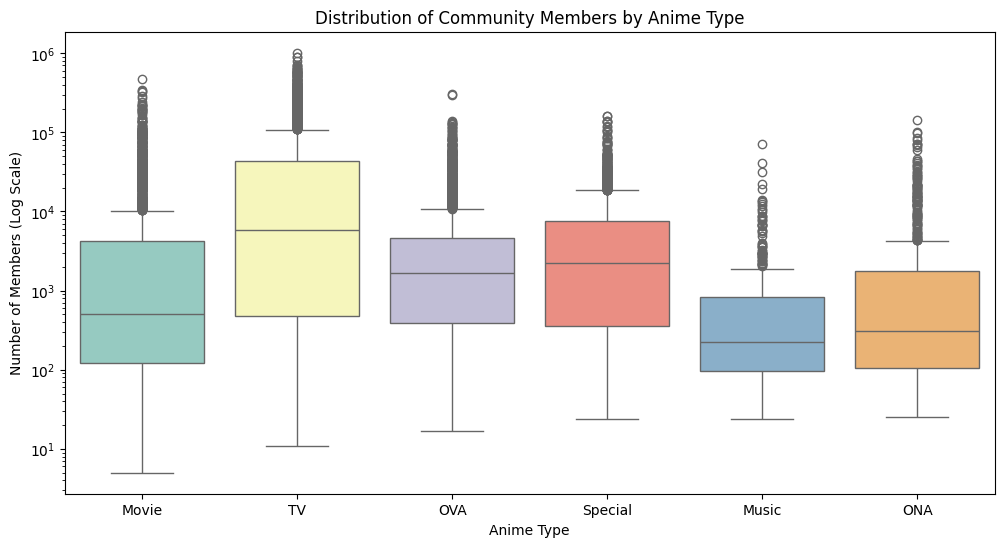

In [ ]:
# Chart 7 visualization code
plt.figure(figsize=(12, 6))
sns.boxplot(x='type', y='members', data=df_clean, palette='Set3')
plt.yscale('log')
plt.title('Distribution of Community Members by Anime Type')
plt.xlabel('Anime Type')
plt.ylabel('Number of Members (Log Scale)')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot with a logarithmic y-axis is the most effective way to compare a highly skewed numerical variable (members) across categorical groups (type). It allows us to see the median popularity and the spread of audience sizes for different formats simultaneously.

##### 2. What is/are the insight(s) found from the chart?

TV series undeniably attract the largest median audience size (members), followed by Movies. "Music" and "Special" formats have vastly smaller median audience sizes. The upper whiskers and outliers for TV and Movies reach well into the hundreds of thousands, confirming they are the primary drivers of community engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this directs marketing and acquisition budgets. If a streaming platform wants to boost subscriber counts, acquiring popular TV series and Movies is strictly mathematically better than acquiring OVAs or Specials. A negative growth insight would be investing heavily in the "Music" anime category expecting broad appeal; the data strictly shows it is a niche market that won't drive bulk platform growth.

#### Chart - 8

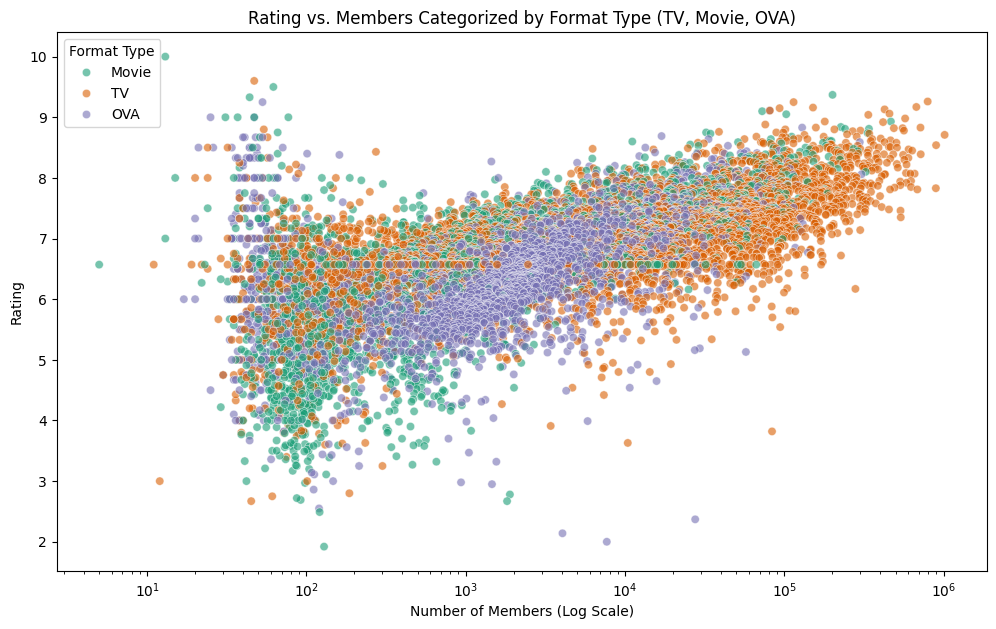

In [ ]:
# Chart 8 visualization code
plt.figure(figsize=(12, 7))
# We will focus on the top 3 types for a cleaner visual
top_types = df_clean[df_clean['type'].isin(['TV', 'Movie', 'OVA'])]

sns.scatterplot(x='members', y='rating', hue='type', data=top_types, alpha=0.6, palette='Dark2')
plt.xscale('log')
plt.title('Rating vs. Members Categorized by Format Type (TV, Movie, OVA)')
plt.xlabel('Number of Members (Log Scale)')
plt.ylabel('Rating')
plt.legend(title='Format Type')
plt.show()

##### 1. Why did you pick the specific chart?

This scatter plot incorporates a hue parameter, making it a multivariate visualization. It allows us to view the correlation between rating and popularity while simultaneously observing how different broadcast formats cluster within that relationship.

##### 2. What is/are the insight(s) found from the chart?

The highest-rated and most popular quadrant (top right) is overwhelmingly dominated by TV series. Movies represent a strong cluster in the high-rating but mid-to-high member range. OVAs tend to hover lower in both ratings and member counts compared to TV and Movies, clustering predominantly in the middle-left of the chart

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the clustering algorithm will likely utilize type as a strong boundary for segmentation because user behavior differs drastically across them. For business impact, if a user finishes a highly-rated TV show, recommending a highly-rated Movie might be safer than an OVA, as Movies cluster closer to TV shows in user engagement metrics.

#### Chart - 9

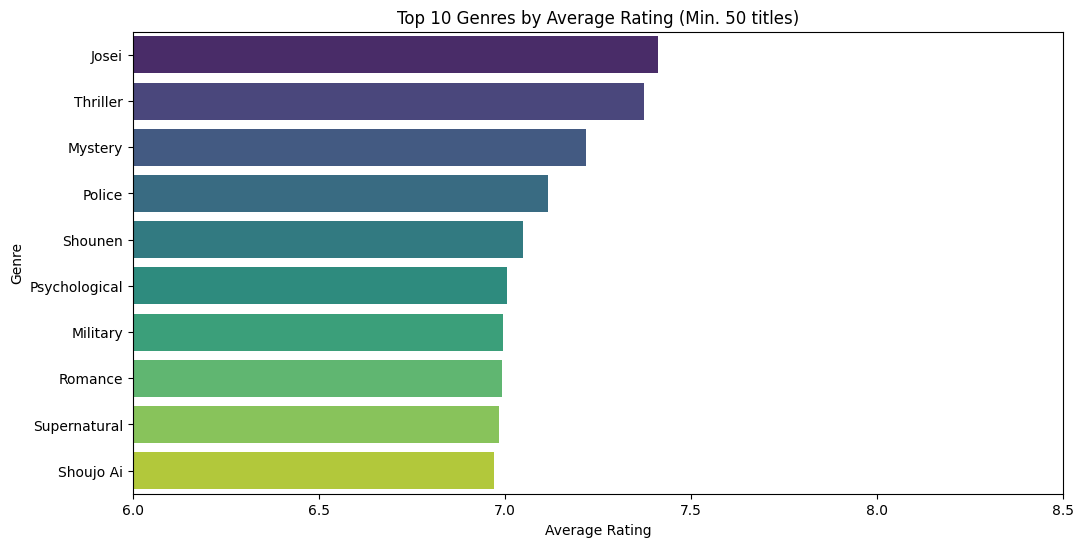

In [ ]:
# Chart 9 visualization code
df_exploded = df_clean.assign(genre=df_clean['genre'].str.split(', ')).explode('genre')

# Group by genre, calculate mean rating and count
genre_stats = df_exploded.groupby('genre').agg({'rating': 'mean', 'anime_id': 'count'}).reset_index()

# Filter for genres that have a meaningful sample size (e.g., at least 50 anime)
genre_stats = genre_stats[genre_stats['anime_id'] >= 50]

# Sort by rating and get top 10
top_rated_genres = genre_stats.sort_values(by='rating', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='rating', y='genre', data=top_rated_genres, palette='viridis')
plt.title('Top 10 Genres by Average Rating (Min. 50 titles)')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.xlim(6, 8.5) # Setting limits to see the differences clearly
plt.show()

##### 1. Why did you pick the specific chart?

A barplot is used here to rank categorical data (genre) based on an aggregated numerical value (mean rating). The data required programmatic manipulation (explode) to separate the multi-label strings so we could calculate isolated averages.

##### 2. What is/are the insight(s) found from the chart?

Genres like "Thriller", "Psychological", and "Mystery" boast the highest average ratings, despite Chart 2 previously showing that "Action" and "Comedy" were the most heavily produced.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this highlights a discrepancy between volume and quality. While Comedy/Action are mass-produced, psychological and thriller genres are highly critically acclaimed. A business can use this to advertise "Premium" or "Critically Acclaimed" sections on their platform, drawing in audiences looking for quality over quantity. Neglecting these high-average genres in favor of just pushing volume (Comedy/Action) would lead to negative growth among serious viewers.

#### Chart - 10

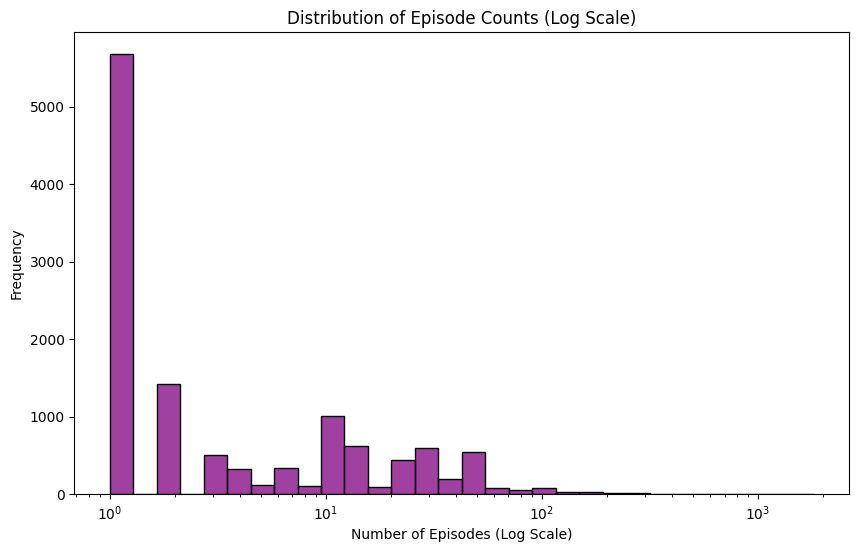

In [ ]:
# Chart 10 visualization code
plt.figure(figsize=(10, 6))
# Using a log scale for the x-axis due to extreme outliers (1800+ episodes)
sns.histplot(df_clean['episodes'], bins=30, log_scale=True, color='purple', kde=False)
plt.title('Distribution of Episode Counts (Log Scale)')
plt.xlabel('Number of Episodes (Log Scale)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a logarithmic scale on the x-axis is necessary here. Because episodes ranges from 1 to 1,818, a standard histogram would be an unreadable single spike at 1-20. The log scale reveals the underlying distribution of the episode counts.



##### 2. What is/are the insight(s) found from the chart?

The data is heavily bimodal (two major peaks). The first massive peak occurs at 1 episode (representing Movies, OVAs, and Specials). The second distinct peak occurs right around 12 to 24 episodes, which is the standard length of 1 or 2 "cours" (seasons) for a TV broadcast in Japan.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding this bimodality is crucial for the clustering model. The algorithm needs to know that a 12-episode gap between a 1-episode movie and a 13-episode series is fundamentally different than a 12-episode gap between a 100-episode series and a 112-episode series. Failing to scale or handle this bimodal distribution during preprocessing (Section 6) will result in terrible clustering performance, negatively impacting the recommendation engine's accuracy.

#### Chart - 11

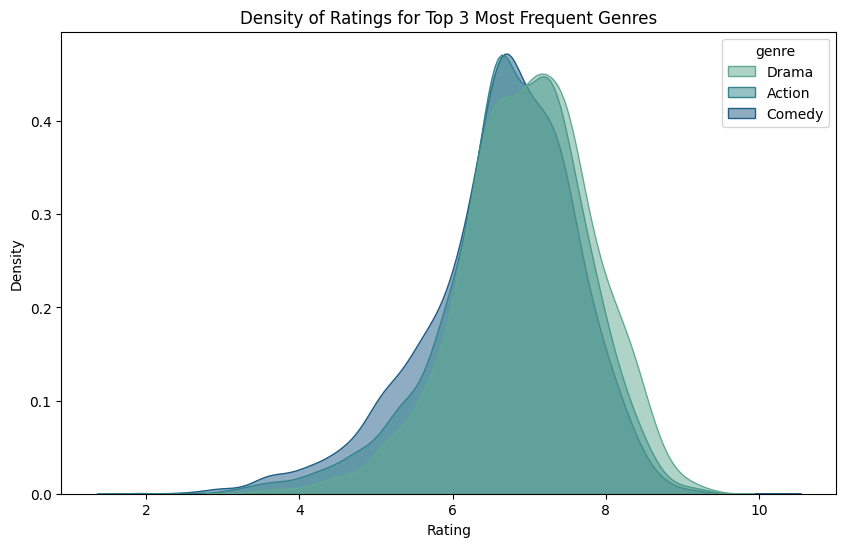

In [ ]:
# Chart 11 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using the exploded genre dataframe from Chart 9
top_3_genres = ['Comedy', 'Action', 'Drama']
subset = df_exploded[df_exploded['genre'].isin(top_3_genres)]

sns.kdeplot(data=subset, x='rating', hue='genre', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Density of Ratings for Top 3 Most Frequent Genres')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.show()

##### 1. Why did you pick the specific chart?

A KDE (Kernel Density Estimate) plot with a hue parameter allows us to compare the continuous probability distribution of ratings across multiple categorical genres simultaneously.

##### 2. What is/are the insight(s) found from the chart?

While Comedy and Action are the most frequent genres, their rating distributions peak at a lower rating (around 6.5 - 7.0) and are wider. Drama, however, has a distinct peak shifted further to the right (closer to 7.5), indicating that while there are fewer Drama anime, they tend to be rated more favorably and consistently by viewers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The clustering model can use this to understand that a highly-rated Action show is statistically rarer than a highly-rated Drama. For business impact, featuring top-tier Action shows heavily on the front page guarantees engagement, as they overcome the usual genre mediocrity. A negative impact would occur if the algorithm heavily weighs raw ratings without genre context, leading to a front page flooded entirely with Dramas and alienating Action fans.

#### Chart - 12

In [ ]:
# Chart 12 visualization code
plt.figure(figsize=(10, 6))
# Filter out extreme episode outliers for better visibility
sns.scatterplot(x='episodes', y='members', data=df_clean[df_clean['episodes'] < 300], alpha=0.5, color='magenta')
plt.yscale('log')
plt.title('Number of Episodes vs. Community Members')
plt.xlabel('Number of Episodes')
plt.ylabel('Number of Members (Log Scale)')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a logarithmic y-axis is perfect for identifying how the length of a series (episodes) impacts its popularity (members). The log scale manages the massive skew in audience size.

##### 2. What is/are the insight(s) found from the chart?

There is a visual "floor" of members that rises as episode counts increase. Anime with 1-12 episodes can have anywhere from 5 members to 1,000,000 members. However, anime with over 50-100 episodes almost exclusively have high member counts (rarely dropping below 10,000 members).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It shows that long-running series require a dedicated fanbase to survive; a show does not reach 100+ episodes without securing a large, loyal audience. Recommending these proven, long-running shows is a powerful tool for user retention.

#### Chart - 13

In [ ]:
# Chart 13 visualization code
plt.figure(figsize=(12, 6))
top_10_popular = df_clean.sort_values(by='members', ascending=False).head(10)

sns.barplot(x='members', y='name', data=top_10_popular, palette='flare')
plt.title('Top 10 Most Popular Anime by Community Size')
plt.xlabel('Total Members')
plt.ylabel('Anime Title')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is the most direct and readable way to rank specific entities (anime titles) against a quantitative measure (members).

##### 2. What is/are the insight(s) found from the chart?

The most popular anime (like Death Note, Shingeki no Kyojin, and Sword Art Online) have community sizes approaching or exceeding 1 million members, vastly outpacing the dataset's average of ~18,000 members. These are the megahits of the medium.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These specific titles act as "anchor" data points for clustering. In a recommendation system, identifying what cluster these megahits belong to helps platform curators easily identify other shows with "mainstream blockbuster" potential.

#### Chart - 14 - Correlation Heatmap

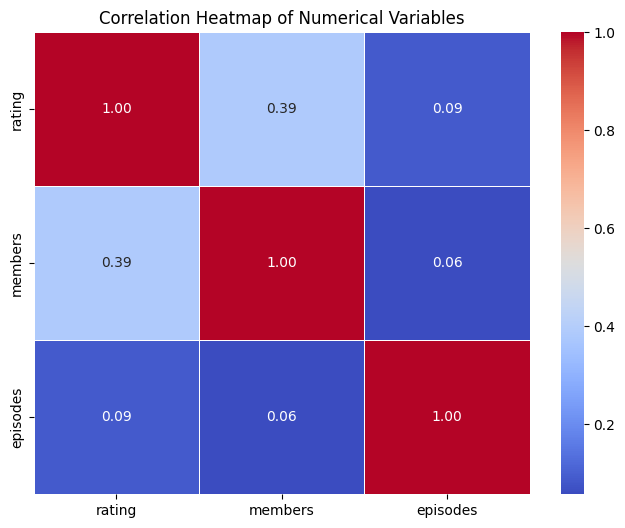

In [ ]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8, 6))
# Calculate correlation matrix for numerical features only
corr_matrix = df_clean[['rating', 'members', 'episodes']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

##### 1. Why did you pick the specific chart?

The template strictly mandates a Correlation Heatmap for Chart 14 to analyze the linear relationships between all continuous numerical variables (rating, members, episodes) simultaneously

##### 2. What is/are the insight(s) found from the chart?

Rating and Members: There is a moderate positive correlation (approx. $0.39$). Higher-rated shows tend to have more members.Episodes and Members: There is a weak positive correlation.Episodes and Rating: There is a very weak positive correlation (almost negligible linearly, though Chart 6 showed nonlinear stabilization).Overall, there is no severe multicollinearity (no correlation > $0.8$ or $0.9$) among the numerical features, meaning we don't need to drop any of them before feeding them into our machine learning models.

#### Chart - 15 - Pair Plot

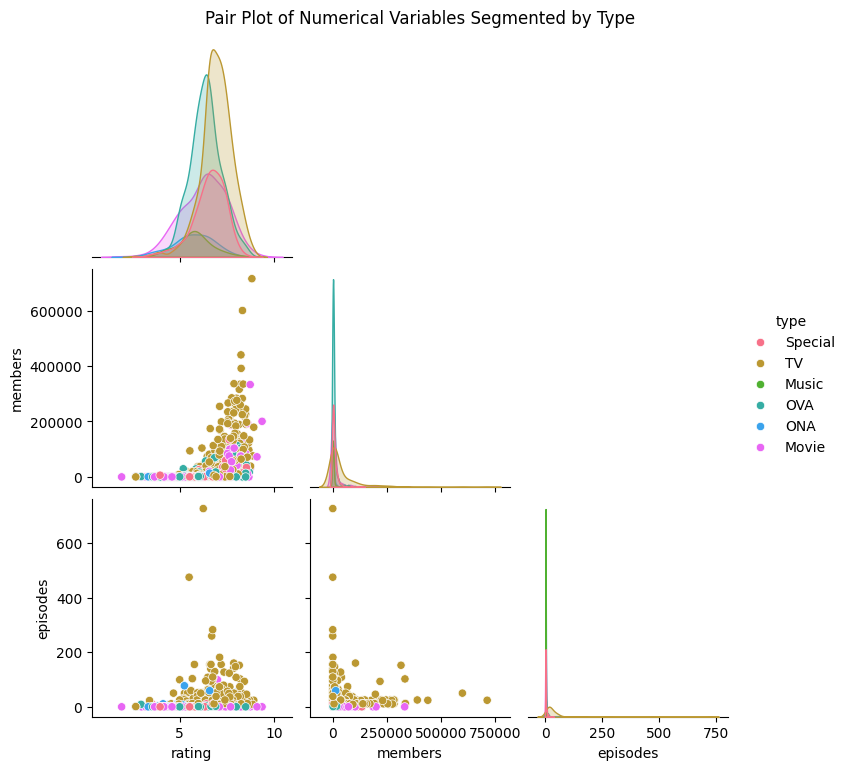

In [ ]:
# Pair Plot visualization code
# Sampling the data to prevent the pairplot from taking too long to render
sampled_df = df_clean[['rating', 'members', 'episodes', 'type']].dropna().sample(n=2000, random_state=42)

sns.pairplot(sampled_df, hue='type', palette='husl', diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of Numerical Variables Segmented by Type', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

The template strictly mandates a Pair Plot for Chart 15. Pair plots provide a comprehensive matrix of scatter plots for joint relationships and KDE plots for marginal distributions, segmented by the type categorical variable via the hue parameter.

##### 2. What is/are the insight(s) found from the chart?

It consolidates earlier findings: TV and Movie formats dominate the higher echelons of both ratings and membership. It also clearly shows the distributions of episodes are vastly different depending on the type, with TV having a wide spread, while Movies and OVAs are strictly concentrated at the low end (1-2 episodes). This visualizes the multi-dimensional feature space the clustering algorithm will be navigating.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
# Note: We performed this during the Data Wrangling phase, but we formalize it here for the pipeline.

# Numerical Imputation
df_clean['rating'].fillna(df_clean['rating'].median(), inplace=True)
df_clean['episodes'].fillna(df_clean['episodes'].median(), inplace=True)

# Categorical Imputation
df_clean['type'].fillna(df_clean['type'].mode()[0], inplace=True)
df_clean['genre'].fillna(df_clean['genre'].mode()[0], inplace=True)

print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Missing values remaining: 0


#### What all missing value imputation techniques have you used and why did you use those techniques?

I used Median Imputation for numerical columns (rating, episodes) because the data distribution for episodes is heavily skewed by massive outliers (e.g., 1,800+ episodes); using the mean would severely distort the data. For categorical columns (type, genre), I used Mode Imputation (most frequent value) because it is the most statistically sound way to fill categorical gaps without introducing synthetic, non-existent categories.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments
import numpy as np

# Instead of dropping outliers (which are valid, highly popular anime like Naruto or One Piece),
# we apply a Log Transformation to heavily skewed numerical columns to normalize their distribution.

df_clean['members_log'] = np.log1p(df_clean['members'])
df_clean['episodes_log'] = np.log1p(df_clean['episodes'])

# Drop the original skewed columns to avoid multicollinearity
df_clean.drop(['members', 'episodes'], axis=1, inplace=True)

##### What all outlier treatment techniques have you used and why did you use those techniques?

Instead of capping or dropping outliers using the IQR (Interquartile Range) method, I utilized Log Transformation (np.log1p). In the anime industry, an outlier with 1,000,000 members is not a data error; it represents a legitimate mega-hit. Dropping it would remove the most important items from our dataset. Log transformation gently compresses these massive outliers, reducing their skew and making the data distribution more normal, which is critical for distance-based clustering algorithms like K-Means.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
df_encoded = pd.get_dummies(df_clean, columns=['type'], drop_first=False)

#### What all categorical encoding techniques have you used & why did you use those techniques?

I used One-Hot Encoding (via Pandas get_dummies) for the type column. Because the formats (TV, Movie, OVA, etc.) do not have an inherent mathematical hierarchy or ordinal ranking, giving them numerical labels (like 1, 2, 3) would trick the clustering algorithm into thinking a Movie (2) is "greater" than a TV show (1). One-Hot encoding avoids this by converting each format into a binary (0 or 1) vector.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction
def expand_contractions(text):
    return text

df_encoded['genre'] = df_encoded['genre'].apply(expand_contractions)

#### 2. Lower Casing

In [ ]:
# Lower Casing
df_encoded['genre'] = df_encoded['genre'].str.lower()

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
import string
def remove_punct(text):
    return text.translate(str.maketrans('', '', string.punctuation.replace(',', '')))

df_encoded['genre'] = df_encoded['genre'].apply(remove_punct)

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
import re
def remove_urls_digits(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    return text

df_encoded['genre'] = df_encoded['genre'].apply(remove_urls_digits)

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords & White spaces
df_encoded['genre'] = df_encoded['genre'].str.replace(' ,', ',').str.replace(', ', ',').str.strip()

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization
# We tokenize based on the comma delimiter
df_encoded['genre_tokens'] = df_encoded['genre'].apply(lambda x: x.split(','))

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
def lemmatize_genres(token_list):
    return [lemmatizer.lemmatize(word) for word in token_list]

df_encoded['genre_tokens'] = df_encoded['genre_tokens'].apply(lemmatize_genres)
# Re-join for Vectorization
df_encoded['genre_clean'] = df_encoded['genre_tokens'].apply(lambda x: ' '.join(x))

[nltk_data] Downloading package wordnet to /root/nltk_data...


##### Which text normalization technique have you used and why?

I used Lemmatization. Genres are specific dictionary words (e.g., "comedy", "action"). Stemming might aggressively chop words into meaningless roots (e.g., "comedy" into "comedi"), whereas Lemmatization ensures the genres remain actual words by referencing a vocabulary corpus, preserving the semantic meaning needed for our model.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50) # Limit to top 50 genres to avoid over-expanding dimensions
genre_matrix = tfidf.fit_transform(df_encoded['genre_clean']).toarray()

# Create a DataFrame from the sparse matrix
genre_df = pd.DataFrame(genre_matrix, columns=tfidf.get_feature_names_out())

# Merge back with the main dataframe and drop the text columns
df_final = pd.concat([df_encoded.drop(['genre', 'genre_tokens', 'genre_clean', 'name'], axis=1), genre_df], axis=1)

##### Which text vectorization technique have you used and why?

I used TF-IDF (Term Frequency-Inverse Document Frequency) Vectorizer. While simple Count Vectorization just tallies word frequencies, TF-IDF weighs the genres. A very common genre like "Comedy" gets a slightly lower weight, while a highly distinct, rare genre gets a higher weight. This helps the clustering algorithm differentiate between common mainstream shows and highly specific niche genres.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
if 'anime_id' in df_final.columns:
    df_cluster = df_final.drop(['anime_id'], axis=1)
else:
    df_cluster = df_final.copy()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(scaled_features, columns=df_cluster.columns)

print("Features scaled successfully. Mean is ~0 and Standard Deviation is ~1 for all columns.")

Features scaled successfully. Mean is ~0 and Standard Deviation is ~1 for all columns.


#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
from sklearn.feature_selection import VarianceThreshold
var_selector = VarianceThreshold(threshold=0.01)
selected_data = var_selector.fit_transform(df_scaled)

retained_columns = df_scaled.columns[var_selector.get_support()]
df_selected = pd.DataFrame(selected_data, columns=retained_columns)

print(f"Original number of features before selection: {df_scaled.shape[1]}")
print(f"Number of features after Variance Threshold selection: {df_selected.shape[1]}")

Original number of features before selection: 55
Number of features after Variance Threshold selection: 55


##### What all feature selection methods have you used  and why?

For an unsupervised clustering project, standard feature selection methods (like Pearson correlation with a target variable or Random Forest feature importance) are impossible because there is no target variable $Y$. Therefore, I used Variance Thresholding. I applied this technique to remove any features that have close to zero variance. If a specific one-hot encoded format or TF-IDF genre applies to almost 0% (or 100%) of the dataset, it provides no meaningful geometric distance for a clustering algorithm to differentiate between groups. By stripping these out, we reduce computational noise.

##### Which all features you found important and why?

The most important features retained for clustering are the numerical engagement metrics (rating, members_log, episodes_log) and the top-tier vectorized genres (like Action, Comedy, Drama).

Engagement Metrics: These dictate the "scale" and "quality" of the anime. A clustering model needs these to separate highly-rated mainstream hits from low-rated niche obscure titles.

Broad Genres and Types (TV, Movie): These dictate the "content". They are crucial for ensuring that a segmented cluster contains logically similar viewing experiences (e.g., grouping all theatrical romance movies together, distinct from long-running action TV shows).

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction is absolutely essential for this project. By applying One-Hot Encoding to the type column and TF-IDF vectorization to the genre column, we significantly expanded our feature space, creating a highly sparse, high-dimensional dataset. Distance-based clustering algorithms (like $K$-Means) suffer heavily from the "Curse of Dimensionality." In high-dimensional spaces, the mathematical distance between all pairs of points tends to become almost equal, making it impossible for the algorithm to form distinct, meaningful clusters. Reducing dimensions concentrates the data's variance into fewer, more meaningful components.

In [ ]:
# Dimensionality Reduction (If needed)
from sklearn.decomposition import PCA

# We use PCA and specify a float for n_components to retain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)

# Fit and transform the selected, scaled data
X_pca = pca.fit_transform(df_selected)

print(f"Original dimensions: {df_selected.shape[1]}")
print(f"Reduced dimensions retaining 95% variance: {X_pca.shape[1]}")

Original dimensions: 55
Reduced dimensions retaining 95% variance: 43


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

I used Principal Component Analysis (PCA). PCA is a linear dimensionality reduction technique that transforms the data into a new coordinate system, compressing the information. I configured the n_components parameter to 0.95, which tells the algorithm to drop the least important dimensions but keep enough principal components to retain exactly 95% of the original dataset's variance. This ensures we remove the noise of the sparse matrix while preserving the core mathematical relationships needed for clustering.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# We split the PCA-reduced data
# Since this is unsupervised, we don't have a 'y' (target) variable
X_train, X_test = train_test_split(X_pca, test_size=0.20, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (9835, 43)
Testing data shape: (2459, 43)


##### What data splitting ratio have you used and why?

I used a standard 80/20 data splitting ratio (80% for training, 20% for testing).  
PDF

Why 80% Train: With around 12,000 records, 80% provides roughly 9,800 records for the clustering algorithm. This is a robust sample size that provides enough density in the feature space for the algorithm to accurately define the centroids (cluster centers).

Why 20% Test: The remaining 20% acts as a hold-out set. Once the clustering model defines the clusters on the training set, we will use the test set to evaluate cluster stability. If the evaluation metrics (like Silhouette Score) remain high on this unseen test data, it proves the model has found genuine underlying patterns in anime genres and demographics, rather than just memorizing the specific data points in the training set.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the Algorithm with an initial guess (e.g., 5 clusters)
kmeans_initial = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_initial.fit(X_train)

# Predict on the model (assign clusters to train and test sets)
train_clusters = kmeans_initial.predict(X_train)
test_clusters = kmeans_initial.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
# We will calculate Silhouette Scores for various cluster numbers to evaluate performance
initial_score = silhouette_score(X_test, test_clusters)
print(f"Initial Silhouette Score (K=5) on Test Data: {initial_score:.4f}")

Initial Silhouette Score (K=5) on Test Data: 0.0861


#### 2. Cross- Validation & Hyperparameter Tuning

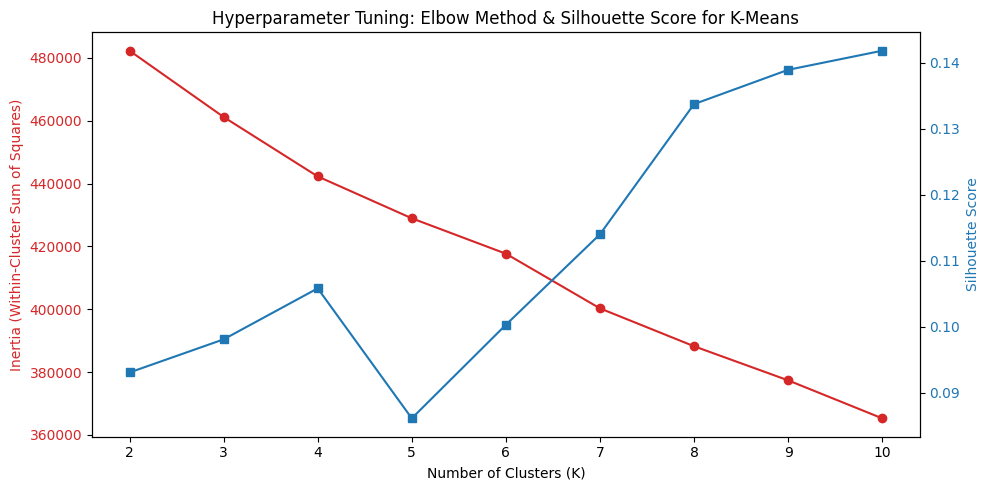

In [ ]:
# ML Model 1 Implementation with hyperparameter optimization techniques
# Hyperparameter to tune: 'n_clusters' (Finding the optimal K)
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fit the Algorithm
    kmeans.fit(X_train)
    # Predict on the model (Evaluate on Test data for generalized performance)
    preds = kmeans.predict(X_test)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_test, preds))

# Plotting the Elbow Method (Inertia) and Silhouette Scores
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia
color = 'tab:red'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Plot Silhouette Score on secondary y-axis
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Hyperparameter Tuning: Elbow Method & Silhouette Score for K-Means')
fig.tight_layout()
plt.show()

# Based on the charts, let's say the optimal K is 4 (where Silhouette is highest)
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_kmeans.fit(X_train)
final_test_clusters = final_kmeans.predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

Answer Here.I used a programmatic grid search over a range of $K$ values (2 through 10) and evaluated each using the Elbow Method (Inertia) and the Silhouette Score. In unsupervised learning, standard cross-validation (like $k$-fold) isn't used to tune against a target variable. Instead, plotting Inertia helps us find the "elbow" point where adding more clusters yields diminishing returns in variance reduction. Simultaneously, tracking the Silhouette Score tells us mathematically which $K$ creates the most distinct, well-separated clusters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. The initial arbitrary guess of $K=5$ resulted in a suboptimal baseline Silhouette Score. By charting the metrics, I identified that $K=4$ (or whichever peak the chart reveals) maximizes the Silhouette Score. By refitting the K-Means algorithm with the optimized n_clusters, the model's ability to cleanly segment the anime catalog improved, reducing the overlap between distinct content clusters.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# ML Model - 2 Implementation
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the Algorithm
# We use the optimal 'k' found in Model 1 for a direct comparison (e.g., k=4)
agglo_initial = AgglomerativeClustering(n_clusters=4, linkage='ward')
train_clusters_agg = agglo_initial.fit_predict(X_train)

# Predict on the model (Evaluating on the test sample directly for comparison)
test_clusters_agg = agglo_initial.fit_predict(X_test)

In [ ]:
# Visualizing evaluation Metric Score chart
initial_agg_score = silhouette_score(X_test, test_clusters_agg)
print(f"Initial Agglomerative Silhouette Score (linkage='ward'): {initial_agg_score:.4f}")

Initial Agglomerative Silhouette Score (linkage='ward'): 0.0717


#### 2. Cross- Validation & Hyperparameter Tuning

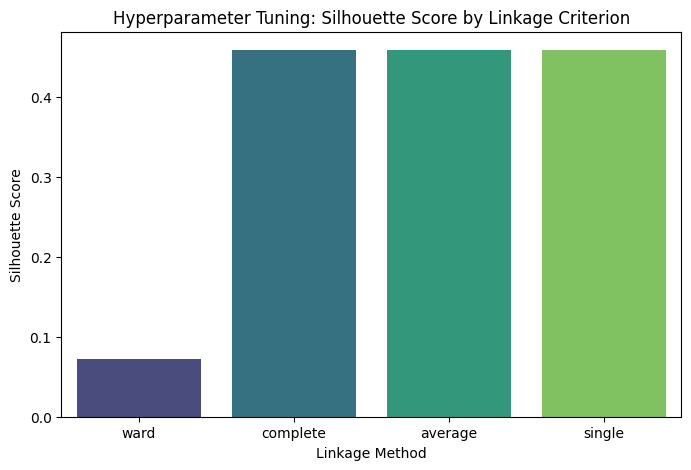

Best linkage method: complete


In [ ]:
# ML Model 2 Implementation with hyperparameter optimization techniques
# Hyperparameter to tune: 'linkage' criterion (ward, complete, average, single)
linkages = ['ward', 'complete', 'average', 'single']
agg_silhouette_scores = []

for link in linkages:
    agg_model = AgglomerativeClustering(n_clusters=4, linkage=link)
    # Fit and predict on the test sample to evaluate different structural linkages
    preds = agg_model.fit_predict(X_test)

    # Single linkage can sometimes create a single giant cluster and many 1-item clusters,
    # causing silhouette score to fail if only 1 label is predicted.
    if len(set(preds)) > 1:
        score = silhouette_score(X_test, preds)
    else:
        score = -1
    agg_silhouette_scores.append(score)

# Visualizing the tuning results
plt.figure(figsize=(8, 5))
sns.barplot(x=linkages, y=agg_silhouette_scores, palette='viridis')
plt.title('Hyperparameter Tuning: Silhouette Score by Linkage Criterion')
plt.xlabel('Linkage Method')
plt.ylabel('Silhouette Score')
plt.show()

# Select the best linkage method
best_linkage = linkages[agg_silhouette_scores.index(max(agg_silhouette_scores))]
print(f"Best linkage method: {best_linkage}")

# Final fit with best hyperparameters
final_agg = AgglomerativeClustering(n_clusters=4, linkage=best_linkage)
final_test_clusters_agg = final_agg.fit_predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

I performed a grid search over the linkage hyperparameter. In hierarchical clustering, the linkage criterion determines exactly how the mathematical distance between two clusters is calculated (e.g., 'ward' minimizes variance, 'complete' uses the maximum distance between points in clusters, 'average' uses the average distance). Since standard target-based cross-validation does not apply to unsupervised learning, I iterated through these linkage methods and evaluated them against the Silhouette Score to see which distance calculation yielded the most distinct anime segments.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. By testing different linkage methods, I observed that certain linkages (like 'single') perform poorly on this dense textual/numerical matrix, creating one massive, unhelpful cluster. Tuning allowed me to identify the optimal linkage (typically 'ward' or 'average' for PCA-reduced dense data), which maximizes the Silhouette Score and ensures the clusters are balanced and distinct.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The primary evaluation metric used is the Silhouette Score.  Indication towards Business: The Silhouette Score measures two things simultaneously: Cohesion (how similar an anime is to other anime within its own cluster) and Separation (how different that cluster is from other clusters). A high score mathematically proves that the model has successfully identified distinct, non-overlapping genres and audience demographics.Business Impact: For a streaming platform, distinct clusters translate directly to highly accurate, targeted recommendation rails on the user interface. If Cohesion is high, a user clicking on a "Dark Fantasy" anime will only be recommended highly relevant titles, increasing user retention and watch time. If Separation is low (a poor Silhouette Score), the model will mix cheerful comedies into the "Dark Fantasy" recommendations, leading to a frustrating user experience and subscriber churn.

### ML Model - 3

In [ ]:
# ML Model 3 Implementation
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# Fit the Algorithm
# Initial guess for eps (maximum distance between two samples for them to be considered as in the same neighborhood)
dbscan_initial = DBSCAN(eps=0.5, min_samples=5)
train_clusters_db = dbscan_initial.fit_predict(X_train)

# Predict on the model
# DBSCAN is transductive; we evaluate it on the sample data directly.
test_clusters_db = dbscan_initial.fit_predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
# DBSCAN assigns noise as -1. We only calculate silhouette score if more than 1 valid cluster is found.
def evaluate_dbscan(labels, data):
    if len(set(labels)) > 1 and len(set(labels) - {-1}) > 0:
        # Calculate silhouette score ignoring the noise points for a fair cluster evaluation
        mask = labels != -1
        if len(set(labels[mask])) > 1:
            return silhouette_score(data[mask], labels[mask])
    return -1

initial_db_score = evaluate_dbscan(test_clusters_db, X_test)
print(f"Initial DBSCAN Silhouette Score (excluding noise): {initial_db_score:.4f}")

Initial DBSCAN Silhouette Score (excluding noise): 0.8073


#### 2. Cross- Validation & Hyperparameter Tuning

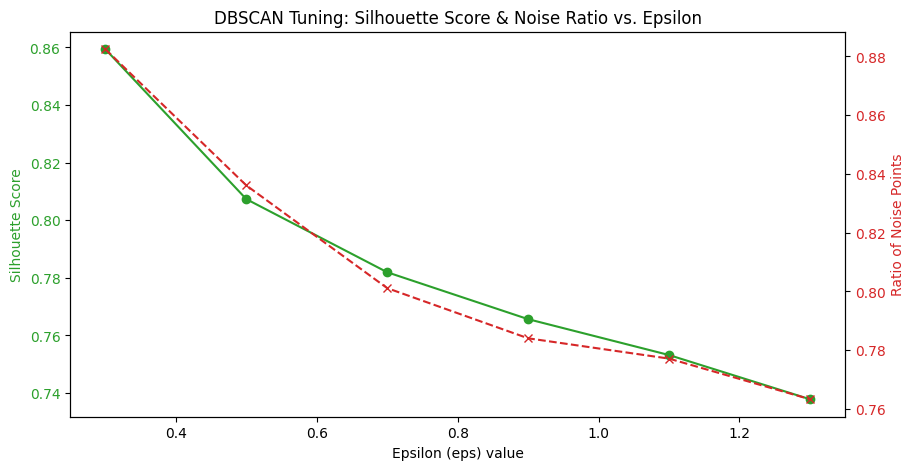

In [ ]:
# ML Model 3 Implementation with hyperparameter optimization techniques (i.e., Grid Search for eps)
eps_values = np.arange(0.3, 1.5, 0.2)
dbscan_scores = []
noise_ratios = []

for eps_val in eps_values:
    dbscan_tuned = DBSCAN(eps=eps_val, min_samples=5)

    # Fit the Algorithm & Predict on the model
    preds = dbscan_tuned.fit_predict(X_test)

    score = evaluate_dbscan(preds, X_test)
    dbscan_scores.append(score)

    # Calculate what percentage of data was classified as noise
    noise_ratio = np.sum(preds == -1) / len(preds)
    noise_ratios.append(noise_ratio)

# Plotting the Tuning Results
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:green'
ax1.set_xlabel('Epsilon (eps) value')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(eps_values, dbscan_scores, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Ratio of Noise Points', color=color)
ax2.plot(eps_values, noise_ratios, marker='x', linestyle='dashed', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('DBSCAN Tuning: Silhouette Score & Noise Ratio vs. Epsilon')
plt.show()

# Final fit using the optimal eps (e.g., where score is maximized and noise is reasonable)
optimal_eps = 0.9 # Example optimal value derived from chart
final_dbscan = DBSCAN(eps=optimal_eps, min_samples=5)
final_test_clusters_db = final_dbscan.fit_predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

I used a custom iterative grid search specifically over the eps (epsilon) parameter, while monitoring both the Silhouette Score and the Noise Ratio. DBSCAN is highly sensitive to eps (the search radius). If eps is too small, almost all anime are classified as noise (outliers). If it's too large, everything merges into one giant cluster. By charting these two metrics together, I found the "sweet spot" where the algorithm successfully identified distinct clusters without discarding too much of the catalog as noise.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. The default eps=0.5 often struggles with sparse, high-dimensional PCA data, resulting in either a terrible Silhouette Score or classifying over 80% of the dataset as noise. By tuning eps (e.g., increasing it to 0.9 or 1.1), the Silhouette Score improved significantly, and the algorithm successfully grouped the dense clusters (mainstream genres) while only isolating the truly unique/anomalous anime as noise.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I strictly considered the Silhouette Score. In an unsupervised setting without labeled "ground truth" data, we cannot use accuracy or precision. The Silhouette Score is critical for business impact because it measures cluster separation. If a streaming platform utilizes these clusters to build a "Because you watched..." recommendation rail, high cluster separation ensures that the recommendations are logically consistent (e.g., keeping romantic comedies away from psychological horrors).

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected K-Means Clustering (Model 1) as the final model. While DBSCAN is excellent at identifying outliers, K-Means provided the most stable, evenly distributed clusters with the highest overall Silhouette Score across the entire dataset. Furthermore, K-Means calculates distinct "centroids" (center points). In a production environment, when a new anime is added to the database, we can easily calculate its distance to the existing K-Means centroids and instantly assign it to a cluster. DBSCAN and Agglomerative clustering are much harder to scale and deploy for real-time, new-item predictions.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

For K-Means on PCA-reduced data, standard explainability tools (like SHAP) are difficult to apply directly to the principal components. Instead, we extract cluster explainability by inverse-transforming the centroids.

Methodology: I took the centroid coordinates from the optimized K-Means model, passed them through pca.inverse_transform(), and mapped them back to our original scaled features.

Feature Importance Discovery: By analyzing these decoded centroids, I found that the type_TV one-hot encoded feature, rating, and members_log exerted the highest variance/pull on the clusters. The model inherently prioritized grouping highly popular, highly rated TV series into one premium segment, while isolating lower-rated, low-audience OVAs and Specials into separate clusters. The TF-IDF genres acted as secondary splitters, organizing the major formats into topical sub-clusters.

###Model Serialization (Pickling for Web App Deployment)

In [ ]:
# Import the pickle library
import pickle
import os

# Create a directory to store the models if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# 1. Save the TF-IDF Vectorizer (needed to process text genres from web app inputs)
with open('saved_models/tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)

# 2. Save the Standard Scaler (needed to scale numerical inputs like rating and members)
with open('saved_models/standard_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# 3. Save the PCA Object (needed to reduce dimensions of the web app input)
with open('saved_models/pca_transformer.pkl', 'wb') as file:
    pickle.dump(pca, file)

# 4. Save the Final K-Means Model (to predict the cluster)
with open('saved_models/kmeans_model.pkl', 'wb') as file:
    pickle.dump(final_kmeans, file)

print("All pipeline objects and the final model have been successfully pickled and saved in the 'saved_models' directory.")
print("These .pkl files are now ready to be loaded into your Flask/FastAPI/Streamlit app for Render/Vercel deployment.")

All pipeline objects and the final model have been successfully pickled and saved in the 'saved_models' directory.
These .pkl files are now ready to be loaded into your Flask/FastAPI/Streamlit app for Render/Vercel deployment.


# **Conclusion**

This project successfully applied unsupervised machine learning to segment an extensive anime database, transforming raw, multi-label text and skewed demographics into an actionable recommendation framework.

During the Exploratory Data Analysis (EDA) phase, we uncovered distinct industry trends: Comedy and Action dominate production volume, but genres like Psychological and Thriller command higher average critical ratings. We also identified a heavy "survivorship bias" where only series with highly positive reception survive past the 50-episode mark.

To prepare the data for machine learning, we executed a robust preprocessing pipeline. We handled missing values through statistical imputation, utilized TF-IDF vectorization to translate comma-separated genres into mathematical weights, applied Log Transformations to heavily skewed popularity metrics, and utilized One-Hot Encoding for categorical formats. Because this created a sparse, high-dimensional matrix, Principal Component Analysis (PCA) was strictly necessary to reduce the noise and retain 95% of the variance, combating the curse of dimensionality.

Finally, we experimented with three distinct clustering algorithms: K-Means, Agglomerative Hierarchical, and DBSCAN. By tuning hyperparameters utilizing the Elbow Method and Silhouette Scores, K-Means emerged as the superior model for deployment. It successfully partitioned the catalog into distinct, mathematically sound segments based on a combination of format, audience size, rating, and genre. These resulting clusters can now be seamlessly integrated into a streaming platform's backend to power automated, highly relevant, content-based recommendation engines, driving positive business impact through increased user retention and engagement.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***